In [1]:
"""
Author: Ruby Lieber 
Affiliation: University of Bristol
Date: 26/06/2025

Description:
This notebook calculates scaling factors and attributable warming for mean temperature over Brazil using the optimal fingerprint method.
"""

'\nAuthor: Ruby Lieber \nAffiliation: University of Bristol\nDate: 26/06/2025\n\nDescription:\nThis notebook calculates scaling factors and attributable warming for mean temperature over Brazil using the optimal fingerprint method.\n'

In [2]:
# Imports 
import os
import re
import xarray as xr
import numpy as np
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.odr import ODR, RealData, Model
from scipy.stats import chi2
from scipy.stats import norm

#### Read in piControl timeseries

In [3]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

pi_can_ts = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/attr_warming/piControl/tas_CanESM5_piControl_r1i1p1f1_annual_timeseries.nc", decode_times=time_coder)
pi_mri_ts = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/attr_warming/piControl/tas_MRI-ESM2-0_piControl_r1i1p1f1_annual_timeseries.nc", decode_times=time_coder)
pi_gfdl_ts = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/attr_warming/piControl/tas_GFDL-CM4_piControl_r1i1p1f1_annual_timeseries.nc", decode_times=time_coder)

piControl_dict = {
    "CanESM5": pi_can_ts,
    "GFDL-CM4": pi_gfdl_ts,
    "MRI-ESM2-0": pi_mri_ts
}

#### Step 1: Pre-process data 

In [4]:
obs_timeseries = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/attr_warming/BR_DWGD_Tmean_annual_timeseries.nc")
obs_smoothed = obs_timeseries.rolling(time=5, center=True, min_periods=1).mean()

In [5]:
# Bias corrected model data (hist and hist-nat)

base_path = "/bp1/geog-tropical/data/BREATHE/attr_warming/bias_corrected_damip_early/"

# Find all tas files
tas_files = glob(os.path.join(base_path, "tas_*.nc"))

# Pattern to extract model, run, and ensemble
pattern = re.compile(
    r"tas_(?P<model>[^_]+)_(?P<run>[^_]+)_(?P<ensemble>r\d+i\d+p\d+f\d+)_bias_corrected_1961_2018\.nc"
)

# Group files by (model, run)
grouped_files = defaultdict(list)
for f in tas_files:
    match = pattern.search(os.path.basename(f))
    if match:
        key = (match["model"], match["run"])
        grouped_files[key].append((match["ensemble"], f))

# Read and combine files into datasets
datasets = {}
for (model, run), ens_files in grouped_files.items():
    # Sort by ensemble 
    ens_files.sort()
    
    # Load all files and assign ensemble coord
    members = []
    for ens_name, f in ens_files:
        ds = xr.open_dataset(f)
        ds = ds.expand_dims(ensemble=[ens_name])
        members.append(ds)

    combined = xr.concat(members, dim="ensemble")
    datasets[(model, run)] = combined

In [6]:
# Load masks
mask_can_gfdl = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/bias_correct_damip/CanESM5_GFDL_mask_2x2.nc")
mask_mri = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/bias_correct_damip/MRI-ESM2_mask_1x1.nc")

# Define slicing and masks by model
masking_config = {
    "CanESM5": {"slice": slice(1, 21), "mask": mask_can_gfdl},
    "GFDL-CM4": {"slice": slice(1, 21), "mask": mask_can_gfdl},
    "MRI-ESM2-0": {"slice": slice(1, 42), "mask": mask_mri},
}

# Apply slices and masks
for (model, run), ds in datasets.items():
    config = masking_config.get(model)
    if config is None:
        continue  # Skip models without a masking config

    lat_slice = config["slice"]
    lon_slice = config["slice"]
    mask = config["mask"]

    # Select and mask
    ds = ds.isel(lat=lat_slice, lon=lon_slice)
    ds = ds.assign_coords(lat=mask.lat, lon=mask.lon)
    ds = ds.where(~np.isnan(mask))

    # Overwrite in place
    datasets[(model, run)] = ds

In [7]:
# Resample to annual
annual = {k: v.copy(deep=True) for k, v in datasets.items()}
for k in annual:
    ds = annual[k]
    
    # Ensure time is datetime64
    if not np.issubdtype(ds.time.dtype, np.datetime64):
        ds = xr.decode_cf(ds)

    # Select tas variable and resample to annual (calendar year)
    tas_annual = ds["tas"].resample(time="YS").mean()

    # Replace dataset with only the annual tas variable
    annual[k] = tas_annual

In [8]:
# Calculate area weighted timeseries
timeseries = {}

for key in annual:
    tas = annual[key]
    weights = np.cos(np.deg2rad(tas.lat))
    weights /= weights.mean()
    ts = tas.weighted(weights).mean(dim=['lat', 'lon'])
    timeseries[key] = ts.rolling(time=5, center=True, min_periods=1).mean()

In [9]:
# Ensemble means 
historical = {}
hist_nat = {}

for (model, run), da in timeseries.items():
    mean_ens = da.mean(dim='ensemble')
    if run == 'historical':
        historical[model] = mean_ens
    elif run == 'hist-nat':
        hist_nat[model] = mean_ens

# Combine into one dataset with models as variables
historical_da = xr.concat(list(historical.values()), dim='model')
historical_da['model'] = list(historical.keys())

hist_nat_da = xr.concat(list(hist_nat.values()), dim='model')
hist_nat_da['model'] = list(hist_nat.keys())

In [10]:
# Compute multi model mean 
hist_nat_mmm = hist_nat_da.mean(dim="model")
historical_mmm = historical_da.mean(dim="model")

#### Step 2: Fingerprints

In [11]:
# Caclulate anomalies 
obs_clim = obs_smoothed.sel(time=slice("1961", "1990")).mean()
obs_anom = obs_smoothed - obs_clim

hist_clim = historical_mmm.sel(time=slice("1961", "1990")).mean()
all_anom = historical_mmm - hist_clim

nat_clim = hist_nat_mmm.sel(time=slice("1961", "1990")).mean()
nat_anom = hist_nat_mmm - nat_clim

ant_anom = all_anom - nat_anom

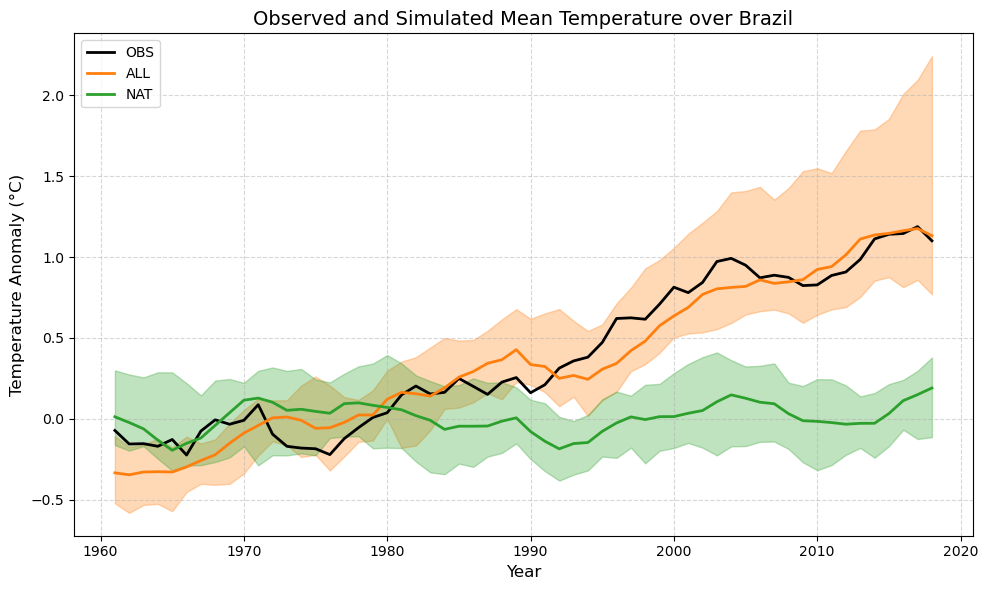

In [12]:
all_anoms = []
nat_anoms = []

for (model, experiment), da in timeseries.items():
    # Compute climatology for this ensemble member
    clim = da.sel(time=slice("1961", "1990")).mean()

    # Subtract climatology to get anomalies
    anom = da - clim

    if experiment == "historical":
        all_anoms.append(anom)
    elif experiment == "hist-nat":
        nat_anoms.append(anom)

# Concatenate along a new 'ensemble' dimension
all_stack = xr.concat(all_anoms, dim="ensemble")
nat_stack = xr.concat(nat_anoms, dim="ensemble")

# Compute 5th and 95th percentiles
all_p5  = all_stack.quantile(0.05, dim="ensemble")
all_p95 = all_stack.quantile(0.95, dim="ensemble")
nat_p5  = nat_stack.quantile(0.05, dim="ensemble")
nat_p95 = nat_stack.quantile(0.95, dim="ensemble")

# Plot
plt.figure(figsize=(10, 6))

# Plot mean lines
obs_anom.plot(label="OBS", c="black", linewidth=2)
all_anom.plot(label="ALL", color="C1", linewidth=2)
nat_anom.plot(label="NAT", color="C2", linewidth=2)

# Plot spreads
plt.fill_between(all_p5.time, all_p5, all_p95, color="C1", alpha=0.3)
plt.fill_between(nat_p5.time, nat_p5, nat_p95, color="C2", alpha=0.3)

# Labels and legend
plt.title("Observed and Simulated Mean Temperature over Brazil", fontsize=14)
plt.ylabel("Temperature Anomaly (°C)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#### Step 3: Scaling factors (1 signal)

>From Allen and Tett (1999): Our null-hypothesis, H0, is that the control simulation of climate variability is an adequate representation of
variability in the real world in the truncated state-space which we are using for the analysis, i.e. the sub-space defned by the first k EOFs of the control run does not include patterns which contain unrealistically low (or high) variance in the control simulation of climate variability. 
>
> If we are unable to reject H0, then we have no explicit reason to distrust uncertainty estimates based on our analysis. This does not, of course, mean that these uncertainty estimates are correct. It may mean only that the tests we have devised are not powerful enough to identify some crucial defciency in model-simulated variability. 
>
> Instead of selecting the truncation level a priori or using some relatively ad hoc criterion, we compare r from Eq. (18) with the standard distribution to establish the maximum value of for which the control still gives a believable estimate of climate noise. 
>
>$$
> r_k^2 \;=\; \mathbf{U}_k^\mathrm{T} \, \hat{\mathbf{C}}_n^{-1} \, \mathbf{U}_k 
\;\;\sim\;\; \chi^2_{\,k-m}
>$$
>
>If a sample of n' uncorrelated observations gives a particular amount of information about the population mean then n = n' × ‘decorrelation time’ is the number of correlated observations required to obtain the same amount of information about the population mean (von Storch & Zwiers, 1999).
>
> The equivalent sample size, with an update by Afyouni et al. 2019, is given by:
>
>$$
>N_{\text{eff}} \;=\; \frac{N}{\,1 + 2 \sum_{k=1}^{N-1} \rho(k)^2 \,}
>$$
>
> where $\rho(k)$ represents the lag-𝑘 autocorrelation coefficient of the time series.

In [ ]:
def build_segments_from_first_half(ts, segment_length, step):
    """Return array of shape (n_segments, segment_length) from first half of ts."""
    vals = np.asarray(ts.values if hasattr(ts, "values") else ts)
    H = len(vals) // 2
    half = vals[:H]
    half = half - half.mean()
    starts = range(0, H - segment_length + 1, step)
    segs = [half[i:i+segment_length] for i in starts if i + segment_length <= H]
    return np.array(segs) if len(segs) else np.empty((0, segment_length))

def segment_corr_at_lag(segments, lag):
    """
    Average correlation between segments separated by 'lag' within the same model.
    Each segment is a vector; we use vector correlation (Pearson) between vectors.
    """
    if len(segments) <= lag:
        return np.nan
    A = segments[:-lag]
    B = segments[lag:]
    # vector-wise Pearson correlation between rows of A and B
    # de-mean each row to be safe (though they already are near zero-mean)
    A = A - A.mean(axis=1, keepdims=True)
    B = B - B.mean(axis=1, keepdims=True)
    num = np.sum(A * B, axis=1)
    den = np.sqrt(np.sum(A*A, axis=1) * np.sum(B*B, axis=1))
    r = num / den
    # guard against tiny-denominator numerical noise
    r = r[np.isfinite(r)]
    return np.nan if r.size == 0 else np.nanmean(r)

def effective_dof_from_segments_eq4(segments_per_model):
    """
    Effective DOF using Eq. (4) from Zwiers & von Storch (1995),
    pooling lag correlations across models, weighting by number of pairs.
    One-series case.
    
    segments_per_model: dict[model_name] = list/array of segment values
                        (each segment is a scalar, e.g., mean over obs window)
    """
    # total number of points across all models
    N_total = sum(len(segs) for segs in segments_per_model.values())

    # Build pooled rho_k for all lags
    pooled_rhos = []
    max_lag = max(len(segs) for segs in segments_per_model.values()) - 1
    for k in range(1, max_lag + 1):
        num, den = 0.0, 0.0
        for segs in segments_per_model.values():
            segs = np.asarray(segs)
            N = len(segs)
            if N > k:
                r = np.corrcoef(segs[:-k], segs[k:])[0, 1]
                if np.isfinite(r):
                    w = N - k  # number of valid pairs at this lag
                    num += r * w
                    den += w
        if den == 0:
            break
        rho_k = num / den
        pooled_rhos.append(rho_k)

    # Since N is large can approximate (1-t/n) as 1 
    # Since overlapping segments from the same model control, ρx​(k)=ρy​(k)=ρ(k)
    # Therefore, Eq. (4) becomes: n_eff = N_total / [1 + 2 * sum_k rho_k^2]
    infl = 1.0 + 2.0 * np.sum(np.array(pooled_rhos) ** 2)
    N_eff_total = N_total / infl

    # per-model DOF (same inflation factor applied to each)
    n_eff_by_model = {
        name: len(segs) / infl for name, segs in segments_per_model.items()
    }

    return N_total, N_eff_total, n_eff_by_model, pooled_rhos

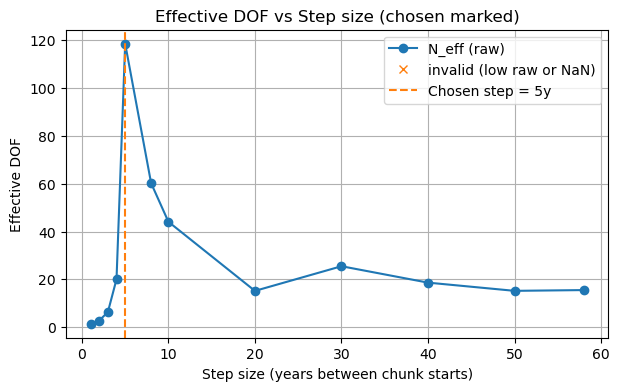

In [14]:
def choose_step_and_plot(piControl_dict, segment_length, steps, 
                         max_lag=200, r_cut=0.02,
                         min_raw=10, fraction=0.95, min_dof=30):
    results = []
    raw_counts = []
    for step in steps:
        segs_per_model = {
            name: build_segments_from_first_half(ts, segment_length, step)
            for name, ts in piControl_dict.items()
        }
        N_total = sum(len(s) for s in segs_per_model.values())
        _, N_eff_total, _, _ = effective_dof_from_segments_eq4(segs_per_model)
        results.append((step, N_total, N_eff_total))
        raw_counts.append(N_total)

    # Convert to arrays
    steps_arr = np.array([r[0] for r in results])
    raw_arr = np.array([r[1] for r in results])
    neff_arr = np.array([r[2] for r in results])

    # Mask invalid / small-sample entries
    valid_mask = (raw_arr >= min_raw) & np.isfinite(neff_arr) & (neff_arr > 0)
    if not valid_mask.any():
        raise RuntimeError("No valid steps: increase data, lower min_raw, or change steps_to_try.")

    neff_valid = neff_arr[valid_mask]
    steps_valid = steps_arr[valid_mask]

    # Choose the threshold-based step
    max_neff = neff_valid.max()
    threshold = fraction * max_neff

    # find smallest step achieving threshold
    candidates = [(s, n) for s, n in zip(steps_valid, neff_valid) if n >= threshold]
    if len(candidates) == 0:
        # fallback: pick step with max neff
        chosen_step, chosen_neff = steps_valid[np.argmax(neff_valid)], np.max(neff_valid)
    else:
        chosen_step, chosen_neff = min(candidates, key=lambda x: x[0])

    # enforce absolute minimum DOF
    if chosen_neff < min_dof:
        print(f"Warning: chosen N_eff={chosen_neff:.1f} < requested min_dof={min_dof}.")
        print("Consider adding models/longer piControl segments or lowering min_dof.")
    # Plot
    plt.figure(figsize=(7,4))
    plt.plot(steps, neff_arr, marker='o', label='N_eff (raw)')
    plt.plot(steps_arr[~valid_mask], neff_arr[~valid_mask], 'x', label='invalid (low raw or NaN)')
    plt.axvline(chosen_step, color='C1', linestyle='--', label=f'Chosen step = {chosen_step}y')
    plt.xlabel("Step size (years between chunk starts)")
    plt.ylabel("Effective DOF")
    plt.title("Effective DOF vs Step size (chosen marked)")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return chosen_step, chosen_neff, results


steps_to_try = [1, 2, 3, 4, 5, 8, 10, 20, 30, 40, 50, 58]
chosen_step, chosen_neff, results = choose_step_and_plot(
    piControl_dict, len(obs_anom), steps_to_try,
    max_lag=200, r_cut=0.02, min_raw=10, fraction=0.95, min_dof=30
)

In [15]:
# Calculate autocorrelation timescale for overlap 
def efolding_timescale(ts):
    ts = ts - np.mean(ts)
    acf = np.correlate(ts, ts, mode='full')
    acf = acf[acf.size // 2:]
    acf /= acf[0]  # normalize

    # find first lag where ACF < 1/e
    target = np.exp(-1)
    below = np.where(acf < target)[0]
    if below.size > 0:
        return below[0]  # lag in timesteps (years if annual data)
    else:
        return len(acf) - 1  # didn't drop below threshold
    
def acf(ts):
    ts = ts - np.mean(ts)
    acf = np.correlate(ts, ts, mode='full')
    acf = acf[acf.size // 2:]
    acf /= acf[0]  # normalize
    return acf 

acf_dict = {model: acf(ts) for model, ts in piControl_dict.items()}

efold_dict = {model: efolding_timescale(ts) for model, ts in piControl_dict.items()}
print(efold_dict)

{'CanESM5': np.int64(4), 'GFDL-CM4': np.int64(4), 'MRI-ESM2-0': np.int64(4)}


(0.0, 10.0)

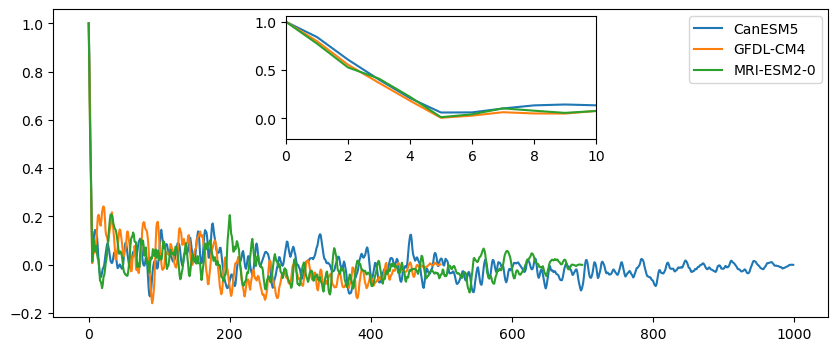

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

# Main plot
ax.plot(acf_dict["CanESM5"], label="CanESM5")
ax.plot(acf_dict["GFDL-CM4"], label="GFDL-CM4")
ax.plot(acf_dict["MRI-ESM2-0"], label="MRI-ESM2-0")
ax.legend(loc="upper right")

ax_inset = inset_axes(ax, width="40%", height="40%", loc='upper center')

# Zoom-in plot
ax_inset.plot(acf_dict["CanESM5"])
ax_inset.plot(acf_dict["GFDL-CM4"])
ax_inset.plot(acf_dict["MRI-ESM2-0"])
ax_inset.set_xlim(0, 10)

> Decorrelation time of 4 years aligns well with maximum efective sample size with lag 5. Decision to use 5-year stride.

In [17]:
# Find truncation level for k 
r2_vals = []

X_vals = all_anom.values.flatten()
y_vals = obs_anom.values

segment_length = len(obs_anom)
offset = 5 # from autocorrelation timescale and effective DOF

# Build segments from first half of piControl
segments = []
for ts in piControl_dict.values():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half = ts_vals[:halfway] - ts_vals[:halfway].mean()

    for start in range(0, len(ts_half) - segment_length + 1, offset):
        seg = ts_half[start:start + segment_length]
        if len(seg) == segment_length:
            segments.append(seg)

segments = np.stack(segments)
cov_eps = np.cov(segments.T)
print(f"Number of segments: {len(segments)}")

# Eigendecomposition
eigvals, eigvecs = np.linalg.eigh(cov_eps)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Loop over k
for k in range(1, len(eigvals) + 1):
    eigvals_k = eigvals[:k]
    eigvecs_k = eigvecs[:, :k]

    # Whitening matrix 
    L = np.diag(1 / np.sqrt(eigvals_k)) @ eigvecs_k.T

    # Whiten data
    X_white = L @ X_vals
    y_white = L @ y_vals

    # TLS fit
    def linear_model(B, x): return B[0] * x
    model = Model(linear_model)
    data = RealData(X_white, y_white)
    odr = ODR(data, model, beta0=[1.0])
    beta_hat = odr.run().beta[0]

    # Compute whitened residuals and test statistic
    resid = y_white - linear_model([beta_hat], X_white)
    r2 = np.sum(resid**2)
    r2_vals.append(r2)

r2_vals = np.array(r2_vals)  

Number of segments: 187


Optimal k: 58


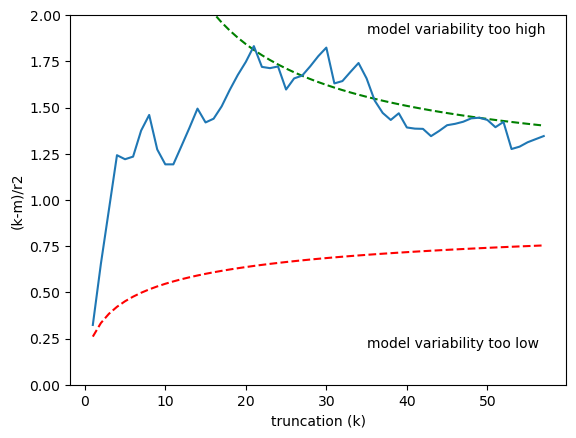

In [18]:
# Check truncation level 
trunk = []
lower = []
upper = []

m=1 

for k, R2_k in enumerate(r2_vals, start=1):
    if k > m:
        t = (k-m) / R2_k
        trunk.append(t)
        q_low = chi2.ppf(0.05, df=k-m)
        q_high = chi2.ppf(0.95, df=k-m)
        lower.append((k - m) / q_high)
        upper.append((k - m) / q_low)
    else:
        trunk.append(np.nan)  # undefined for k=1
        lower.append(np.nan)
        upper.append(np.nan)

trunk = np.array(trunk)

valid_k = [
    k for k, t, lo, up in zip(range(1, len(trunk) + 1), trunk, lower, upper)
    if not np.isnan(t) and lo <= t <= up
]

optimal_k = max(valid_k) if valid_k else None

print(f"Optimal k: {optimal_k}")

plt.plot(lower, 'r--', label="5% bound")
plt.plot(upper, 'g--', label="95% bound")

plt.ylim(0,2)

# Labels 
plt.plot(trunk)
plt.ylabel("(k-m)/r2")
plt.xlabel("truncation (k)")

plt.annotate("model variability too high", (35,1.9));
plt.annotate("model variability too low", (35,0.2));

In [19]:
# ONE-SIGNAL REGRESSION (ALL):

# ------------------------------
# STEP 1: Prepare pre-whitened inputs
# ------------------------------
 
segments = []

# Estimate covariance matrix from FIRST half of PI control
for model_key, ts in piControl_dict.items():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half = ts_vals[:halfway]
    ts_half = ts_half - ts_half.mean()

    for start in range(0, len(ts_half) - segment_length + 1, offset):
        segment = ts_half[start:start + segment_length]
        if len(segment) == segment_length:
            segments.append(segment)

segments = np.stack(segments)
cov_eps = np.cov(segments.T)

# Eigendecomposition
eigvals, eigvecs = np.linalg.eigh(cov_eps)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

eigvals_k = eigvals[:optimal_k]
eigvecs_k = eigvecs[:, :optimal_k]

# Build whitening matrix 
Lambda_inv_sqrt_k = np.diag(1 / np.sqrt(eigvals_k))
L = Lambda_inv_sqrt_k @ eigvecs_k.T  

# Pre-whiten observations and fingerprint
X_vals = all_anom.values.flatten()
y_vals = obs_anom.values

X_white = L @ X_vals
y_white = L @ y_vals

# ------------------------------
# STEP 1: Fit TLS to get best β and residual norm
# ------------------------------

# Define TLS model
def linear_model(B, x):
    return B[0] * x

model = Model(linear_model)
data = RealData(X_white, y_white)
odr = ODR(data, model, beta0=[1.0])
output = odr.run()

beta_hat = output.beta[0]  # MLE of scaling factor
resid_best = y_white - linear_model([beta_hat], X_white)
rss_best = np.sum(resid_best**2)

# ------------------------------
# STEP 2: Evaluate likelihood profile
# ------------------------------

# Extract second half of control
segments_2 = []
for model_key, ts in piControl_dict.items():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half2 = ts_vals[halfway:]
    ts_half2 = ts_half2 - ts_half2.mean()

    for start in range(0, len(ts_half2) - segment_length + 1, offset):
        segment = ts_half2[start:start + segment_length]
        if len(segment) == segment_length:
            segments_2.append(segment)

segments_2 = np.stack(segments_2)

# Whiten each segment using the same L
eps_white_2 = segments_2 @ L.T  

# Estimate variance of whitened noise (~1 if perfect whitening)
sigma2 = np.var(eps_white_2, axis=0).mean()

# Range of beta values to test
beta_range = np.linspace(beta_hat - 1.0, beta_hat + 1.0, 500)
delta_logL = []

for b in beta_range:
    resid_b = y_white - linear_model([b], X_white)
    rss_b = np.sum(resid_b**2)
    delta = (rss_b - rss_best) / (2 * sigma2)
    delta_logL.append(delta)

delta_logL = np.array(delta_logL)

# ------------------------------
# STEP 3: Determine CI bounds using MLE
# ------------------------------

threshold = chi2.ppf(0.90, df=1) / 2  # DOF equal to number of signals 

# Mask of acceptable betas
ci_mask = delta_logL <= threshold
beta_CI = beta_range[ci_mask]

# Extract bounds
lower_all_tls_like = beta_CI.min()
upper_all_tls_like = beta_CI.max()

# Rename beta_hat
b_all_tls = beta_hat.copy()

print(f"β̂: {beta_hat:.2f}")
print(f"90% CI: [{lower_all_tls_like:.2f}, {upper_all_tls_like:.2f}]")

β̂: 1.06
90% CI: [0.80, 1.12]


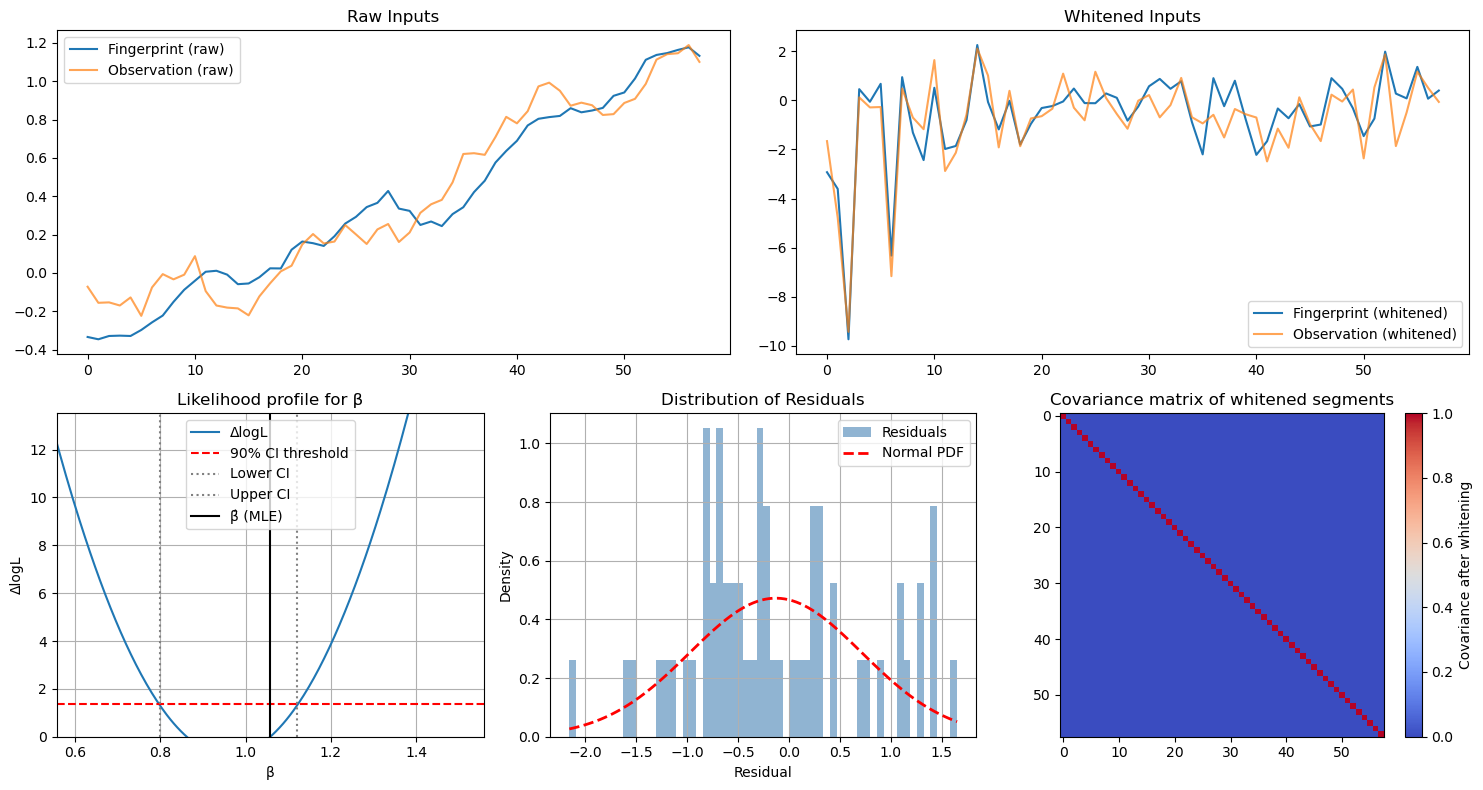

In [20]:
# Plot checks 

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 6)

# Panel 1: Raw inputs 
ax0 = fig.add_subplot(gs[0, 0:3])
ax0.plot(X_vals, label='Fingerprint (raw)')
ax0.plot(y_vals, label='Observation (raw)', alpha=0.7)
ax0.set_title("Raw Inputs")
ax0.legend()

# Panel 2: Whitened inputs 
ax1 = fig.add_subplot(gs[0, 3:6])
ax1.plot(X_white, label='Fingerprint (whitened)')
ax1.plot(y_white, label='Observation (whitened)', alpha=0.7)
ax1.set_title("Whitened Inputs")
ax1.legend()

# Panel 3: Likelihood profile 
ax2 = fig.add_subplot(gs[1, 0:2])
ax2.plot(beta_range, delta_logL, label='ΔlogL')
ax2.axhline(threshold, color='red', linestyle='--', label='90% CI threshold')
ax2.axvline(lower_all_tls_like, color='grey', linestyle=':', label='Lower CI')
ax2.axvline(upper_all_tls_like, color='grey', linestyle=':', label='Upper CI')
ax2.axvline(beta_hat, color='black', linestyle='-', label='β̂ (MLE)')
ax2.set_xlabel('β')
ax2.set_ylabel('ΔlogL')
ax2.set_title('Likelihood profile for β')
ax2.set_ylim(0, threshold * 10)
ax2.set_xlim(beta_hat - 0.5, beta_hat + 0.5)
ax2.legend()
ax2.grid(True)

# Panel 4: Residual distribution 
ax3 = fig.add_subplot(gs[1, 2:4])
mu, std = np.mean(resid_best), np.std(resid_best)
count, bins, _ = ax3.hist(resid_best, bins=58, density=True, alpha=0.6, color='steelblue', label='Residuals')
x = np.linspace(bins[0], bins[-1], 100)
ax3.plot(x, norm.pdf(x, mu, std), 'r--', linewidth=2, label='Normal PDF')
ax3.set_title('Distribution of Residuals')
ax3.set_xlabel('Residual')
ax3.set_ylabel('Density')
ax3.legend()
ax3.grid(True)

# Panel 5: Covariance matrix 
ax4 = fig.add_subplot(gs[1, 4:6])
cov_check = np.cov((segments @ L.T).T)
im = ax4.imshow(cov_check, cmap='coolwarm')
plt.colorbar(im, ax=ax4, label='Covariance after whitening')
ax4.set_title('Covariance matrix of whitened segments')

plt.tight_layout()

#### Residual consistency test
>Equation 19 from Allen and Tett (1999) implies the sum of squares of whitened residuals is equivalent to the test statistic:
>$$
>\sum_{i=1}^{k} \frac{(\,y_i - \tilde{\beta} x_i\,)^{2}}{{\lambda}_i^2}
\;\;\sim\;\; \chi^2_{\,k-1}
>$$

In [21]:
# -----------------------------
# 1) Test statistic for observed residuals
# -----------------------------
T_obs = np.sum(resid_best**2)       # already whitened residuals
p = 1                                # number of signals in TLS fit 
df = optimal_k - p                   # χ^2 degrees of freedom for the residual test

# -----------------------------
# 2) Build OVERLAPPING second-half control segments
# -----------------------------
segments_2 = []
for model_key, ts in piControl_dict.items():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half2 = ts_vals[halfway:]
    ts_half2 = ts_half2 - ts_half2.mean()

    # Overlapping segments with your chosen step (= offset)
    for start in range(0, len(ts_half2) - segment_length + 1, offset):
        seg = ts_half2[start:start + segment_length]
        if len(seg) == segment_length:
            segments_2.append(seg)

segments_2 = np.stack(segments_2)
n_segments = len(segments_2)
print(f"Found {n_segments} overlapping segments in second half (step={offset})")

# -----------------------------
# 3) Whiten control segments (use SAME whitening from first half)
# -----------------------------
segments_2_white = segments_2 @ L.T   # shape: (n_segments, optimal_k)

# -----------------------------
# 4) Compute control-distribution of T directly from segments
#    (no bootstrap: one TLS fit per segment)
# -----------------------------
T_ctrl = np.empty(n_segments)
for i in range(n_segments):
    y_seg = segments_2_white[i]

    # 1-signal TLS fit in whitened space (same as for obs)
    def linear_model(B, x):
        return B[0] * x

    model = Model(linear_model)
    data = RealData(X_white, y_seg)
    odr = ODR(data, model, beta0=[1.0])
    out = odr.run()
    beta_i = out.beta[0]
    resid_i = y_seg - linear_model([beta_i], X_white)

    # Residual consistency test statistic (already whitened): sum of squares
    T_ctrl[i] = np.sum(resid_i**2)

# -----------------------------
# 5) Empirical and theoretical p-values
# -----------------------------
# Empirical p-value from control segments (with a +1 correction to avoid 0/1 extremes)
p_val_empirical = (np.sum(T_ctrl >= T_obs) + 1.0) / (n_segments + 1.0)

# Theoretical χ^2 p-value with df = k - p
p_val_theory = 1.0 - chi2.cdf(T_obs, df=df)

print(f"T_obs: {T_obs:.3f}")
print(f"Empirical p-val (overlapping segments): {p_val_empirical:.3f}")
print(f"Theoretical χ^2 p-val (df={df}): {p_val_theory:.3f}")

if p_val_empirical > 0.05:
    print("Residuals are consistent with internal variability (empirical test).")
else:
    print("Residuals are NOT consistent with internal variability (empirical test).")

Found 187 overlapping segments in second half (step=5)
T_obs: 42.361
Empirical p-val (overlapping segments): 0.910
Theoretical χ^2 p-val (df=57): 0.926
Residuals are consistent with internal variability (empirical test).


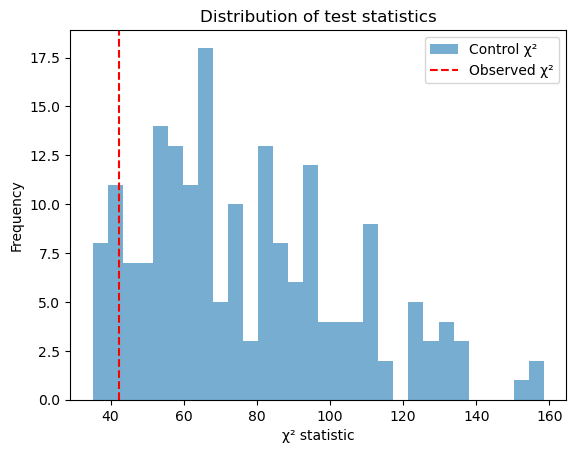

In [22]:
# Plot distribution of test statistics 
plt.hist(T_ctrl, bins=30, alpha=0.6, label='Control χ²')
plt.axvline(T_obs, color='r', linestyle='--', label='Observed χ²')
plt.legend()
plt.title('Distribution of test statistics')
plt.xlabel('χ² statistic')
plt.ylabel('Frequency')
plt.show()

#### Step 4: Scaling factors (2 signal)

In [23]:
# Find truncation level for k (two-signal case)
r2_vals = []

# Flatten predictors and observations
X_vals = np.column_stack((ant_anom.values.flatten(),
                          nat_anom.values.flatten()))
y_vals = obs_anom.values

segment_length = len(obs_anom)
offset = 5  # from autocorrelation timescale and effective DOF

# Build segments from first half of piControl
segments = []
for ts in piControl_dict.values():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half = ts_vals[:halfway] - ts_vals[:halfway].mean()
    for start in range(0, len(ts_half) - segment_length + 1, offset):
        seg = ts_half[start:start + segment_length]
        if len(seg) == segment_length:
            segments.append(seg)

segments = np.stack(segments)
cov_eps = np.cov(segments.T)

# Eigendecomposition
eigvals, eigvecs = np.linalg.eigh(cov_eps)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Loop over k
for k in range(2, len(eigvals) + 1):  # k must be > m = 2
    eigvals_k = eigvals[:k]
    eigvecs_k = eigvecs[:, :k]

    # Whitening matrix
    L = np.diag(1 / np.sqrt(eigvals_k)) @ eigvecs_k.T

    # Whiten predictors
    X_white = np.column_stack([L @ X_vals[:, 0],
                               L @ X_vals[:, 1]])
    # Whiten obs
    y_white = L @ y_vals

    # Two-signal TLS fit
    def linear_model(B, x):
        return B[0] * x[0] + B[1] * x[1]

    model = Model(linear_model)
    data = RealData(X_white.T, y_white)  # note shape for ODR: x has shape (m, n)
    odr = ODR(data, model, beta0=[1.0, 1.0])
    beta_hat = odr.run().beta

    # Compute residuals and test statistic
    resid = y_white - linear_model(beta_hat, X_white.T)
    r2 = np.sum(resid**2)
    r2_vals.append(r2)

# Convert to array
r2_vals = np.array(r2_vals)

Optimal k 2-sig: 57


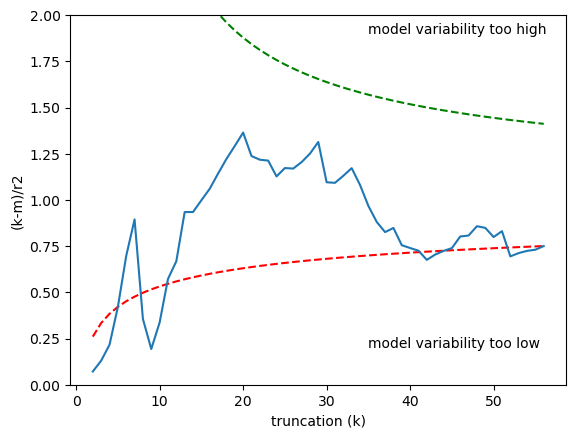

In [24]:
# Check truncation level 
trunk = []
lower = []
upper = []

m=2

for k, R2_k in enumerate(r2_vals, start=1):
    if k > m:
        t = (k-m) / R2_k
        trunk.append(t)
        q_low = chi2.ppf(0.05, df=k-m)
        q_high = chi2.ppf(0.95, df=k-m)
        lower.append((k - m) / q_high)
        upper.append((k - m) / q_low)
    else:
        trunk.append(np.nan)  # undefined for k=1,2
        lower.append(np.nan)
        upper.append(np.nan)

trunk = np.array(trunk)

valid_k = [
    k for k, t, lo, up in zip(range(1, len(trunk) + 1), trunk, lower, upper)
    if not np.isnan(t) and lo <= t <= up
]

optimal_k_2sig = max(valid_k) if valid_k else None

print(f"Optimal k 2-sig: {optimal_k_2sig}")

plt.plot(lower, 'r--', label="5% bound")
plt.plot(upper, 'g--', label="95% bound")

plt.ylim(0,2)

# Labels 
plt.plot(trunk)
plt.ylabel("(k-m)/r2")
plt.xlabel("truncation (k)")

plt.annotate("model variability too high", (35,1.9));
plt.annotate("model variability too low", (35,0.2));

In [25]:
# TWO-SIGNAL REGRESSION (ANT and NAT) with whitening setup

# ------------------------------
# STEP 1: Construct whitening matrix from first-half piControl
# ------------------------------

segments = []

# Estimate covariance matrix from FIRST half of PI control
for model_key, ts in piControl_dict.items():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half = ts_vals[:halfway]
    ts_half = ts_half - ts_half.mean()

    for start in range(0, len(ts_half) - segment_length + 1, offset):
        segment = ts_half[start:start + segment_length]
        if len(segment) == segment_length:
            segments.append(segment)

segments = np.stack(segments)
cov_eps = np.cov(segments.T)

# Eigendecomposition
eigvals, eigvecs = np.linalg.eigh(cov_eps)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Keep top k (from two-signal optimal k selection)
eigvals_k = eigvals[:optimal_k_2sig]
eigvecs_k = eigvecs[:, :optimal_k_2sig]

# Build whitening matrix 
Lambda_inv_sqrt_k = np.diag(1 / np.sqrt(eigvals_k))
L = Lambda_inv_sqrt_k @ eigvecs_k.T  

# ------------------------------
# STEP 2: Pre-whiten predictors and observations
# ------------------------------

# Flatten the two predictors and the observation
X_vals = np.column_stack((ant_anom.values.flatten(),
                          nat_anom.values.flatten()))
y_vals = obs_anom.values

# Whiten each predictor 
X_white = np.zeros((X_vals.shape[1], L.shape[0]))  
for i in range(X_vals.shape[1]):
    X_white[i, :] = L @ X_vals[:, i]

# Whiten the observation
y_white = L @ y_vals

# ------------------------------
# STEP 3: Fit TLS to get best β and residual norm
# ------------------------------

def linear_model(B, x):
    return B[0] * x[0] + B[1] * x[1]

model = Model(linear_model)
data = RealData(X_white, y_white)
odr_obj = ODR(data, model, beta0=[1.0, 1.0])
output = odr_obj.run()

beta_hat = output.beta  # array of 2 betas
resid_best = y_white - linear_model(beta_hat, X_white)
rss_best = np.sum(resid_best**2)

# ------------------------------
# STEP 4: Evaluate likelihood profile
# ------------------------------

# Extract second half of control
segments_2 = []
for model_key, ts in piControl_dict.items():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half2 = ts_vals[halfway:]
    ts_half2 = ts_half2 - ts_half2.mean()

    for start in range(0, len(ts_half2) - segment_length + 1, offset):
        segment = ts_half2[start:start + segment_length]
        if len(segment) == segment_length:
            segments_2.append(segment)

segments_2 = np.stack(segments_2)

# Whiten each segment using the same L
eps_white_2 = segments_2 @ L.T  

# Estimate variance of whitened noise (~1 if perfect whitening)
sigma2 = np.var(eps_white_2, axis=0).mean()

# Create grid around beta_hat for each parameter
beta1_range = np.linspace(beta_hat[0] - 1.0, beta_hat[0] + 1.0, 100)
beta2_range = np.linspace(beta_hat[1] - 1.0, beta_hat[1] + 1.0, 100)

delta_logL = np.zeros((len(beta1_range), len(beta2_range)))

for i, b1 in enumerate(beta1_range):
    for j, b2 in enumerate(beta2_range):
        resid_b = y_white - linear_model([b1, b2], X_white)
        rss_b = np.sum(resid_b**2)
        delta_logL[i, j] = (rss_b - rss_best) / (2 * sigma2)

# ------------------------------
# STEP 5: Determine CI bounds
# ------------------------------

threshold = chi2.ppf(0.90, df=2) / 2  # For 90% CI, 2 DOF
ci_mask = delta_logL <= threshold

beta1_CI = beta1_range[np.any(ci_mask, axis=1)]
beta2_CI = beta2_range[np.any(ci_mask, axis=0)]

lower_beta_ant = beta1_CI.min()
upper_beta_ant = beta1_CI.max()
lower_beta_nat = beta2_CI.min()
upper_beta_nat = beta2_CI.max()

b_ant_tls = beta_hat[0]
b_nat_tls = beta_hat[1]

print(f"β̂_ANT: {b_ant_tls:.2f}  90% CI: [{lower_beta_ant:.2f}, {upper_beta_ant:.2f}]")
print(f"β̂_NAT: {b_nat_tls:.2f}  90% CI: [{lower_beta_nat:.2f}, {upper_beta_nat:.2f}]")

β̂_ANT: 1.05  90% CI: [0.56, 1.41]
β̂_NAT: 2.17  90% CI: [1.17, 2.30]


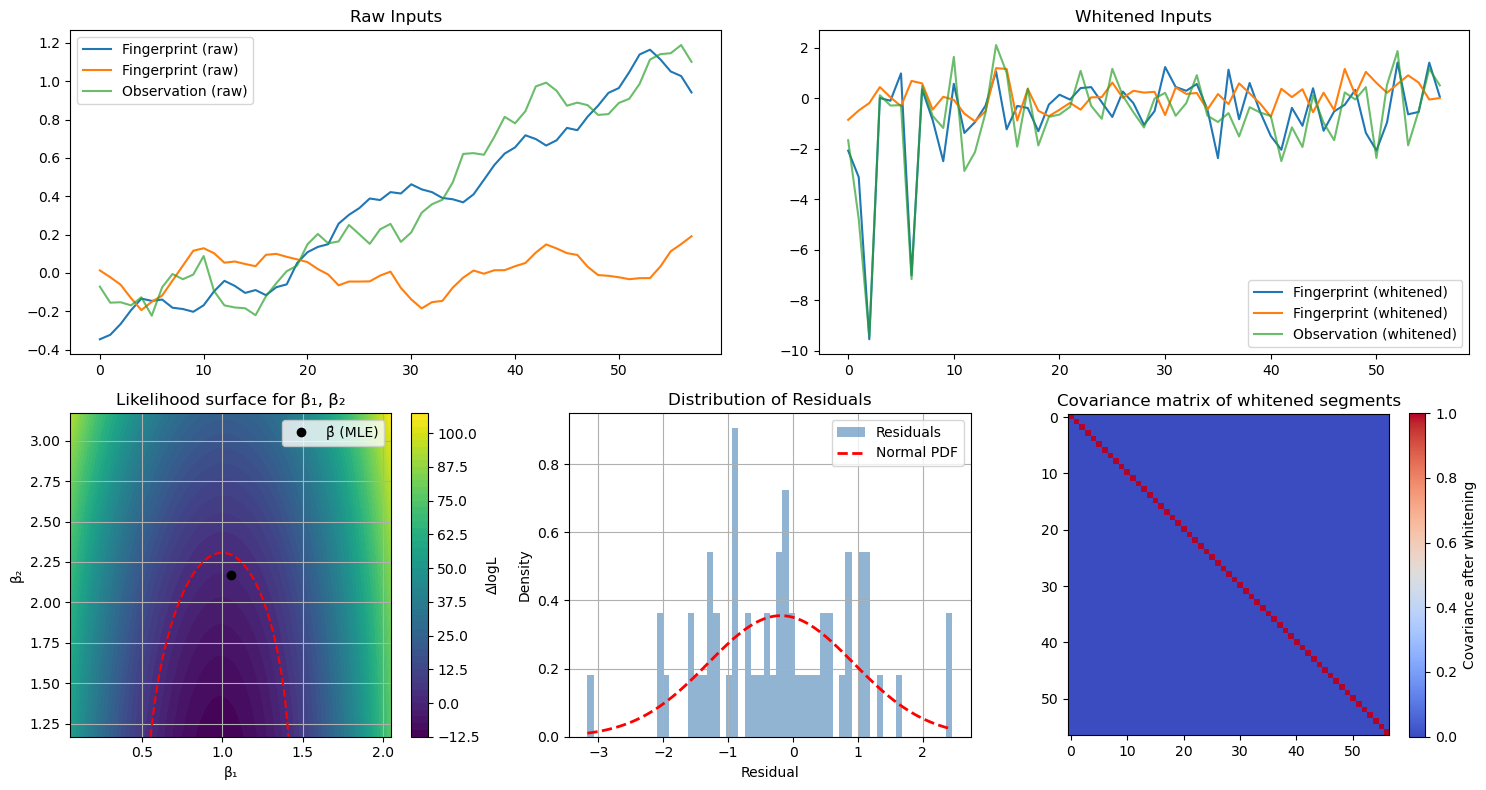

In [26]:
# Plot checks 

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 6)

# Panel 1: Raw inputs 
ax0 = fig.add_subplot(gs[0, 0:3])
ax0.plot(X_vals, label='Fingerprint (raw)')
ax0.plot(y_vals, label='Observation (raw)', alpha=0.7)
ax0.set_title("Raw Inputs")
ax0.legend()

# Panel 2: Whitened inputs 
ax1 = fig.add_subplot(gs[0, 3:6])
ax1.plot(X_white.T, label='Fingerprint (whitened)')
ax1.plot(y_white, label='Observation (whitened)', alpha=0.7)
ax1.set_title("Whitened Inputs")
ax1.legend()

# Panel 3: Likelihood surface for β1, β2
ax2 = fig.add_subplot(gs[1, 0:2])

# Contour plot
c = ax2.contourf(beta1_range, beta2_range, delta_logL.T, levels=50, cmap='viridis')
fig.colorbar(c, ax=ax2, label='ΔlogL')

# Add CI threshold contour
ax2.contour(beta1_range, beta2_range, delta_logL.T,
            levels=[threshold], colors='red', linestyles='--', linewidths=1.5)

# Mark MLE point
ax2.plot(beta_hat[0], beta_hat[1], 'ko', label='β̂ (MLE)')

ax2.set_xlabel('β₁')
ax2.set_ylabel('β₂')
ax2.set_title('Likelihood surface for β₁, β₂')
ax2.legend()
ax2.grid(True)


# Panel 4: Residual distribution 
ax3 = fig.add_subplot(gs[1, 2:4])
mu, std = np.mean(resid_best), np.std(resid_best)
count, bins, _ = ax3.hist(resid_best, bins=58, density=True, alpha=0.6, color='steelblue', label='Residuals')
x = np.linspace(bins[0], bins[-1], 100)
ax3.plot(x, norm.pdf(x, mu, std), 'r--', linewidth=2, label='Normal PDF')
ax3.set_title('Distribution of Residuals')
ax3.set_xlabel('Residual')
ax3.set_ylabel('Density')
ax3.legend()
ax3.grid(True)

# Panel 5: Covariance matrix 
ax4 = fig.add_subplot(gs[1, 4:6])
cov_check = np.cov((segments @ L.T).T)
im = ax4.imshow(cov_check, cmap='coolwarm')
plt.colorbar(im, ax=ax4, label='Covariance after whitening')
ax4.set_title('Covariance matrix of whitened segments')

plt.tight_layout()

In [27]:
# -----------------------------
# 1) Test statistic for observed residuals
# -----------------------------
T_obs = np.sum(resid_best**2)  # already whitened residuals
p = 2                          # number of signals
df = optimal_k_2sig - p             # Eq. (19): df = k - m

# -----------------------------
# 2) Build OVERLAPPING second-half control segments
# -----------------------------
segments_2 = []
for model_key, ts in piControl_dict.items():
    ts_vals = ts.values
    halfway = len(ts_vals) // 2
    ts_half2 = ts_vals[halfway:]
    ts_half2 = ts_half2 - ts_half2.mean()

    # Overlapping segments (step = chosen offset)
    for start in range(0, len(ts_half2) - segment_length + 1, offset):
        seg = ts_half2[start:start + segment_length]
        if len(seg) == segment_length:
            segments_2.append(seg)

segments_2 = np.stack(segments_2)
n_segments = len(segments_2)
print(f"Found {n_segments} overlapping segments in second half (step={offset})")

# -----------------------------
# 3) Whiten control segments (same whitening as first half)
# -----------------------------
segments_2_white = segments_2 @ L.T  # shape: (n_segments, optimal_k)

# -----------------------------
# 4) Compute T for each control segment
# -----------------------------
T_ctrl = np.empty(n_segments)
for i in range(n_segments):
    pseudo_obs_white = segments_2_white[i]

    # TLS fit for 2 signals
    def linear_model(B, x):
        return B[0] * x[0] + B[1] * x[1]
    
    model = Model(linear_model)
    data = RealData(X_white, pseudo_obs_white)
    odr = ODR(data, model, beta0=[1.0, 1.0])
    output = odr.run()
    beta_i = output.beta
    resid_i = pseudo_obs_white - linear_model(beta_i, X_white)

    # Residual test statistic (already whitened residuals)
    T_ctrl[i] = np.sum(resid_i**2)

# -----------------------------
# 5) Empirical and theoretical p-values
# -----------------------------
p_val_empirical = (np.sum(T_ctrl >= T_obs) + 1.0) / (n_segments + 1.0)
p_val_theory = 1.0 - chi2.cdf(T_obs, df=df)

print(f"T_obs: {T_obs:.3f}")
print(f"Empirical p-val: {p_val_empirical:.3f}")
print(f"Theoretical p-val (df={df}): {p_val_theory:.3f}")

if p_val_empirical > 0.05:
    print("Residuals are consistent with internal variability (empirical test).")
else:
    print("Residuals are NOT consistent with internal variability (empirical test).")

Found 187 overlapping segments in second half (step=5)
T_obs: 73.905
Empirical p-val: 1.000
Theoretical p-val (df=55): 0.045
Residuals are consistent with internal variability (empirical test).


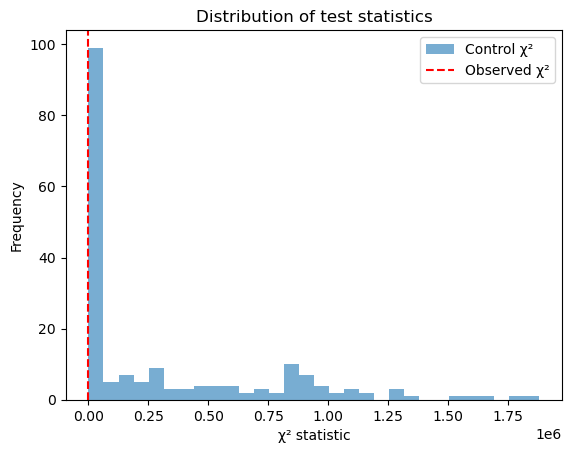

In [28]:
# Plot distribution of test statistics 
plt.hist(T_ctrl, bins=30, alpha=0.6, label='Control χ²')
plt.axvline(T_obs, color='r', linestyle='--', label='Observed χ²')
plt.legend()
plt.title('Distribution of test statistics')
plt.xlabel('χ² statistic')
plt.ylabel('Frequency')
plt.show()

#### Step 4: Attributable warming

In [29]:
# Mean anomaly over 2000–2018 for ANT, NAT, ALL
xbar_ant = ant_anom.sel(time=slice("2000", "2018")).mean().values
xbar_nat = nat_anom.sel(time=slice("2000", "2018")).mean().values
xbar_all = all_anom.sel(time=slice("2000", "2018")).mean().values

# Compute attributable warming
attrib_ant = xbar_ant * b_ant_tls
attrib_nat = xbar_nat * b_nat_tls
attrib_all = xbar_all * b_all_tls

attrib_ant_lower = xbar_ant * lower_beta_ant
attrib_ant_upper = xbar_ant * upper_beta_ant

attrib_nat_lower = xbar_nat * lower_beta_nat
attrib_nat_upper = xbar_nat * upper_beta_nat

attrib_all_lower = xbar_all * lower_all_tls_like
attrib_all_upper = xbar_all * upper_all_tls_like

### Step 5: Plot 

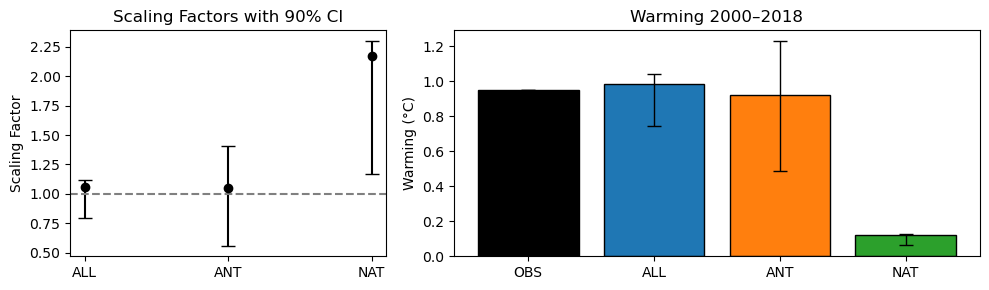

In [30]:
obs_warming = obs_anom.sel(time=slice("2000", "2018")).mean(dim='time')

scaling_factors = [b_all_tls, b_ant_tls, b_nat_tls]
scaling_labels = ['ALL', 'ANT', 'NAT']
scaling_lowers = [lower_all_tls_like, lower_beta_ant, lower_beta_nat] 
scaling_uppers = [upper_all_tls_like, upper_beta_ant, upper_beta_nat] 

warming = [obs_warming, attrib_all, attrib_ant, attrib_nat]
warming_labels = ['OBS', 'ALL', 'ANT', 'NAT']
warming_colors = ['black', '#1f77b4', '#ff7f0e', '#2ca02c']

warming_lowers = [obs_warming, attrib_all_lower, attrib_ant_lower, attrib_nat_lower]
warming_uppers = [obs_warming, attrib_all_upper, attrib_ant_upper, attrib_nat_upper]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), gridspec_kw={'width_ratios': [0.6, 1]})

# --- Left: Scaling Factors ---
ax = axes[0]
x = np.arange(len(scaling_factors))

errors = [
    np.array(scaling_factors) - np.array(scaling_lowers),
    np.array(scaling_uppers) - np.array(scaling_factors)
]

ax.errorbar(
    x, scaling_factors, yerr=errors, fmt='o', capsize=5, color='black'
)
ax.axhline(1, color='grey', linestyle='--', label='Perfect agreement')
ax.set_xticks(x)
ax.set_xticklabels(scaling_labels)
ax.set_ylabel('Scaling Factor')
ax.set_title('Scaling Factors with 90% CI')

# --- Right: Attributable Warming ---
ax = axes[1]
x = np.arange(len(warming))

bars = ax.bar(
    x, warming, capsize=5,
    color=warming_colors, edgecolor='black'
)

# Add confidence bars 
warming_errors = [
    np.array(warming) - np.array(warming_lowers),
    np.array(warming_uppers) - np.array(warming)
]

# Add error bars manually
ax.errorbar(
    x, warming, yerr=warming_errors, fmt='none',  # no marker
    ecolor='black', capsize=5, elinewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(warming_labels)
ax.set_ylabel('Warming (°C)')
ax.set_title('Warming 2000–2018')

plt.tight_layout()

### Save off warming and thresholds for plotting 

In [31]:
np.savez("/bp1/geog-tropical/data/BREATHE/attr_warming/plotting/SF_CI_warming.npz",
         scaling_factors=scaling_factors,
         scaling_lowers=scaling_lowers,
         scaling_uppers=scaling_uppers,
         warming=warming,
         warming_lowers=warming_lowers,
         warming_uppers=warming_uppers)